# Pitcher Valuation Distribution: Holdout vs Direct-Rate

Comparing pitcher valuations between steamer-only (`holdout`) and routed ensemble with `use_direct_rates=True` (`direct-rate`) for ZAR-reformed, across 2024 and 2025 seasons.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from fantasy_baseball_manager.db.connection import create_connection

# Data lives in main repo, not worktree
db_path = Path("/Users/edward/Projects/fbm/data/fbm.db")
conn = create_connection(db_path)

query = """
SELECT v.player_id, v.season, v.version, v.value, v.rank, v.position,
       p.name_first || ' ' || p.name_last AS player_name
FROM valuation v
JOIN player p ON p.id = v.player_id
WHERE v.system = 'zar-reformed'
  AND v.version IN ('holdout', 'direct-rate')
  AND v.player_type = 'pitcher'
  AND v.season IN (2024, 2025)
ORDER BY v.season, v.version, v.value DESC
"""
df = pd.read_sql(query, conn)
df.head()

,player_id,season,version,value,rank,position,player_name
0,20023,2024,direct-rate,100.22,1,P,Zack Wheeler
1,3000,2024,direct-rate,96.08,2,P,Spencer Strider
2,10728,2024,direct-rate,79.25,4,P,Tyler Glasnow
3,5500,2024,direct-rate,60.79,6,P,Corbin Burnes
4,2935,2024,direct-rate,55.85,8,P,Tarik Skubal


In [2]:
# Summary stats by season and version
summary = df.groupby(["season", "version"])["value"].describe()
summary

count      mean        std  min  25%  50%  75%     max
season version                                                            
2024   direct-rate  369.0  4.227778  12.919663  0.0  0.0  0.0  0.0  100.22
       holdout      369.0  4.227615  11.984627  0.0  0.0  0.0  0.0   89.75
2025   direct-rate  346.0  4.508642  13.248448  0.0  0.0  0.0  0.0   90.73
       holdout      346.0  4.508728  13.154189  0.0  0.0  0.0  0.0   95.39

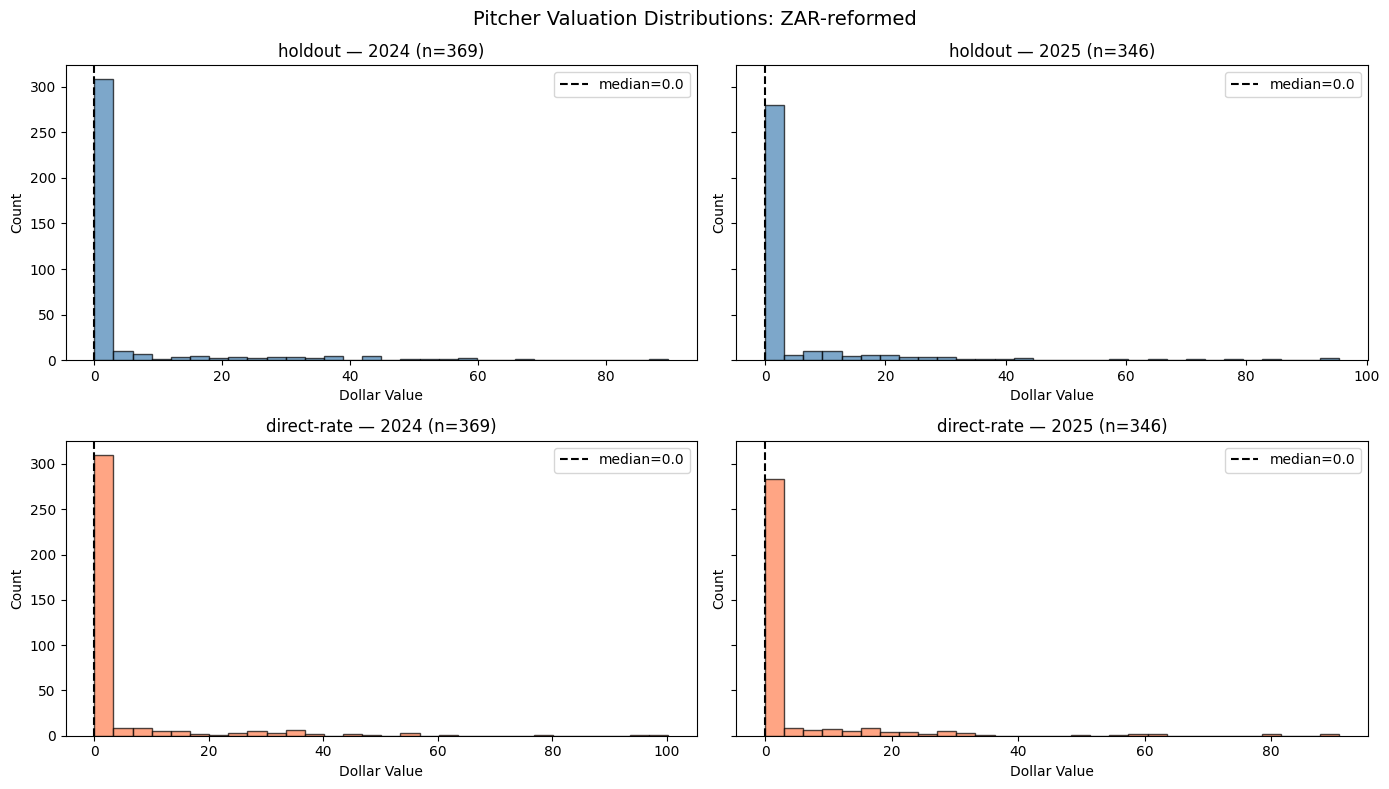

In [3]:
# Histograms: holdout vs direct-rate pitcher valuations
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey="row")

for col, season in enumerate([2024, 2025]):
    for row, version in enumerate(["holdout", "direct-rate"]):
        ax = axes[row, col]
        vals = df[(df["season"] == season) & (df["version"] == version)]["value"]
        ax.hist(vals, bins=30, edgecolor="black", alpha=0.7, color="steelblue" if version == "holdout" else "coral")
        ax.set_title(f"{version} — {season} (n={len(vals)})")
        ax.set_xlabel("Dollar Value")
        ax.set_ylabel("Count")
        ax.axvline(vals.median(), color="black", linestyle="--", label=f"median={vals.median():.1f}")
        ax.legend()

fig.suptitle("Pitcher Valuation Distributions: ZAR-reformed", fontsize=14)
fig.tight_layout()
plt.show()

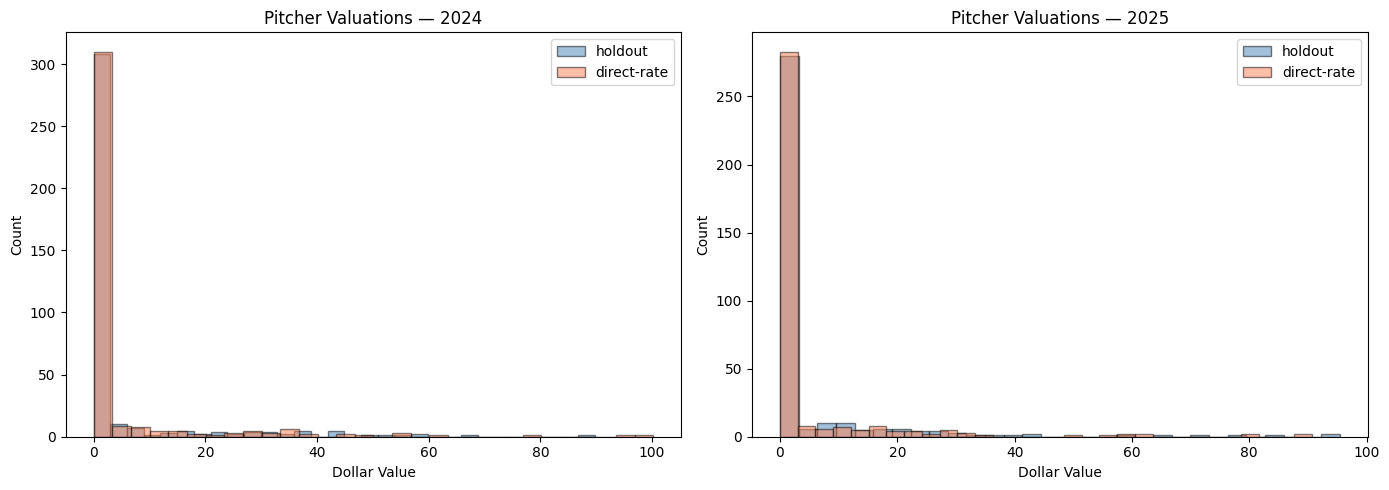

In [4]:
# Overlaid histograms for easier comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, season in enumerate([2024, 2025]):
    ax = axes[i]
    holdout = df[(df["season"] == season) & (df["version"] == "holdout")]["value"]
    direct = df[(df["season"] == season) & (df["version"] == "direct-rate")]["value"]
    ax.hist(holdout, bins=30, alpha=0.5, label="holdout", color="steelblue", edgecolor="black")
    ax.hist(direct, bins=30, alpha=0.5, label="direct-rate", color="coral", edgecolor="black")
    ax.set_title(f"Pitcher Valuations — {season}")
    ax.set_xlabel("Dollar Value")
    ax.set_ylabel("Count")
    ax.legend()

fig.tight_layout()
plt.show()

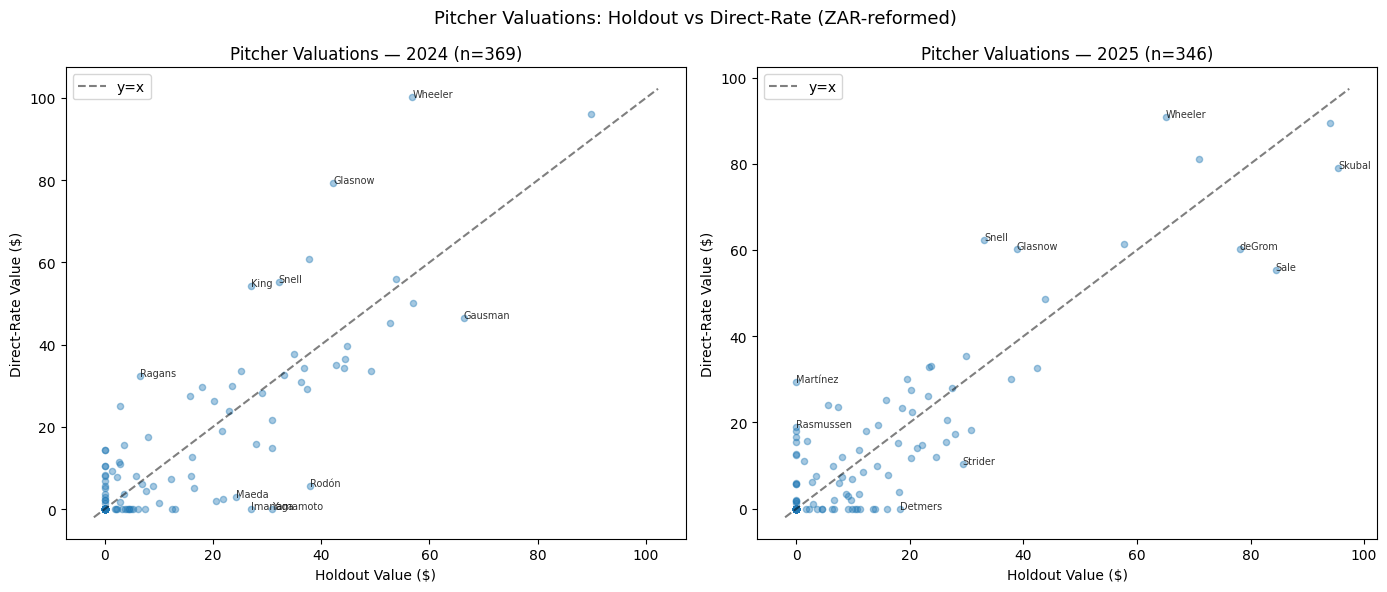

In [5]:
# Scatter: holdout vs direct-rate valuations (matched by player_id)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, season in enumerate([2024, 2025]):
    ax = axes[i]
    holdout = df[(df["season"] == season) & (df["version"] == "holdout")][["player_id", "value", "player_name"]].rename(
        columns={"value": "holdout"}
    )
    direct = df[(df["season"] == season) & (df["version"] == "direct-rate")][["player_id", "value"]].rename(
        columns={"value": "direct_rate"}
    )
    merged = holdout.merge(direct, on="player_id")

    ax.scatter(merged["holdout"], merged["direct_rate"], alpha=0.4, s=20)
    lims = [
        min(merged["holdout"].min(), merged["direct_rate"].min()) - 2,
        max(merged["holdout"].max(), merged["direct_rate"].max()) + 2,
    ]
    ax.plot(lims, lims, "k--", alpha=0.5, label="y=x")
    ax.set_xlabel("Holdout Value ($)")
    ax.set_ylabel("Direct-Rate Value ($)")
    ax.set_title(f"Pitcher Valuations — {season} (n={len(merged)})")
    ax.legend()

    # Annotate top movers
    merged["delta"] = merged["direct_rate"] - merged["holdout"]
    top_movers = merged.nlargest(5, "delta")
    bottom_movers = merged.nsmallest(5, "delta")
    for _, row in pd.concat([top_movers, bottom_movers]).iterrows():
        ax.annotate(row["player_name"].split()[-1], (row["holdout"], row["direct_rate"]), fontsize=7, alpha=0.8)

fig.suptitle("Pitcher Valuations: Holdout vs Direct-Rate (ZAR-reformed)", fontsize=13)
fig.tight_layout()
plt.show()

In [6]:
# Top 10 biggest movers (up and down) for each season
for season in [2024, 2025]:
    holdout = df[(df["season"] == season) & (df["version"] == "holdout")][
        ["player_id", "value", "player_name", "position"]
    ].rename(columns={"value": "holdout"})
    direct = df[(df["season"] == season) & (df["version"] == "direct-rate")][["player_id", "value"]].rename(
        columns={"value": "direct_rate"}
    )
    merged = holdout.merge(direct, on="player_id")
    merged["delta"] = merged["direct_rate"] - merged["holdout"]

    print(f"\n=== {season} — Top 10 gainers ===")
    display(
        merged.nlargest(10, "delta")[["player_name", "position", "holdout", "direct_rate", "delta"]].reset_index(
            drop=True
        )
    )

    print(f"\n=== {season} — Top 10 losers ===")
    display(
        merged.nsmallest(10, "delta")[["player_name", "position", "holdout", "direct_rate", "delta"]].reset_index(
            drop=True
        )
    )


=== 2024 — Top 10 gainers ===


,player_name,position,holdout,direct_rate,delta
0,Zack Wheeler,P,56.86,100.22,43.36
1,Tyler Glasnow,P,42.24,79.25,37.01
2,Mike King,RP,26.97,54.27,27.30
3,Cole Ragans,P,6.47,32.30,25.83
4,Blake Snell,P,32.17,55.32,23.15
5,Corbin Burnes,P,37.77,60.79,23.02
6,Bailey Ober,P,2.78,25.09,22.31
7,Nick Martínez,RP,0.00,14.44,14.44
8,Jakob Junis,RP,0.00,14.42,14.42
9,A. J. Puk,RP,3.56,15.51,11.95



=== 2024 — Top 10 losers ===


,player_name,position,holdout,direct_rate,delta
0,Carlos Rodón,P,38.00,5.59,-32.41
1,Yoshinobu Yamamoto,P,30.99,0.00,-30.99
2,Shota Imanaga,P,26.94,0.00,-26.94
3,Kenta Maeda,RP,24.26,2.96,-21.30
4,Kevin Gausman,P,66.33,46.36,-19.97
5,Steven Matz,RP,21.80,2.57,-19.23
6,Shane Bieber,P,20.62,1.94,-18.68
7,Jesús Luzardo,P,30.88,14.79,-16.09
8,Framber Valdez,P,49.11,33.46,-15.65
9,Mason Miller,RP,13.04,0.00,-13.04



=== 2025 — Top 10 gainers ===


,player_name,position,holdout,direct_rate,delta
0,Nick Martínez,RP,0.00,29.34,29.34
1,Blake Snell,P,33.11,62.30,29.19
2,Zack Wheeler,P,65.06,90.73,25.67
3,Tyler Glasnow,P,38.83,60.12,21.29
4,Drew Rasmussen,P,0.00,18.98,18.98
5,Bailey Ober,P,5.49,23.97,18.48
6,Kris Bubic,RP,0.00,17.91,17.91
7,Tanner Houck,P,0.00,16.58,16.58
8,Reynaldo López,P,7.39,23.69,16.30
9,Seth Lugo,P,0.00,15.53,15.53



=== 2025 — Top 10 losers ===


,player_name,position,holdout,direct_rate,delta
0,Chris Sale,P,84.42,55.32,-29.10
1,Spencer Strider,P,29.28,10.27,-19.01
2,Reid Detmers,RP,18.25,0.00,-18.25
3,Jacob deGrom,P,78.14,60.21,-17.93
4,Tarik Skubal,P,95.39,78.97,-16.42
5,Steven Matz,RP,15.93,0.00,-15.93
6,Carlos Rodón,P,18.09,3.88,-14.21
7,Félix Bautista,RP,13.91,0.00,-13.91
8,Kevin Gausman,P,13.44,0.00,-13.44
9,Luis Castillo,P,24.65,11.90,-12.75


In [7]:
# SP vs RP breakdown — do direct rates affect one group more?
for season in [2024, 2025]:
    holdout = df[(df["season"] == season) & (df["version"] == "holdout")][["player_id", "value", "position"]].rename(
        columns={"value": "holdout"}
    )
    direct = df[(df["season"] == season) & (df["version"] == "direct-rate")][["player_id", "value"]].rename(
        columns={"value": "direct_rate"}
    )
    merged = holdout.merge(direct, on="player_id")
    merged["delta"] = merged["direct_rate"] - merged["holdout"]
    # Use position from holdout side
    merged["position"] = merged["position"]

    print(f"\n=== {season} — Delta by position ===")
    display(merged.groupby("position")["delta"].agg(["count", "mean", "median", "std", "min", "max"]).round(2))


=== 2024 — Delta by position ===


,count,mean,median,std,min,max
position,,,,,,
P,164,-0.07,0.0,8.34,-32.41,43.36
RP,205,0.06,0.0,3.92,-21.30,27.30



=== 2025 — Delta by position ===


,count,mean,median,std,min,max
position,,,,,,
P,199,0.20,0.0,6.31,-29.10,29.19
RP,147,-0.26,0.0,4.61,-18.25,29.34


In [8]:
# Top 10 pitchers by value — holdout vs direct-rate vs actuals (WAR)
for season in [2024, 2025]:
    print(f"\n{'=' * 80}")
    print(f"  SEASON {season} — Top 10 Pitcher Valuations")
    print(f"{'=' * 80}")

    holdout = (
        df[(df["season"] == season) & (df["version"] == "holdout")][["player_id", "value", "player_name", "position"]]
        .rename(columns={"value": "holdout_val"})
        .nlargest(10, "holdout_val")
        .reset_index(drop=True)
    )

    direct = (
        df[(df["season"] == season) & (df["version"] == "direct-rate")][
            ["player_id", "value", "player_name", "position"]
        ]
        .rename(columns={"value": "direct_val"})
        .nlargest(10, "direct_val")
        .reset_index(drop=True)
    )

    # Get actual WAR for context
    war_query = f"""
    SELECT player_id, war FROM pitching_stats
    WHERE season = {season}
    """
    war_df = pd.read_sql(war_query, conn)

    print("\n--- Holdout (steamer-only) top 10 ---")
    h10 = holdout.merge(war_df, on="player_id", how="left")
    h10.columns = ["player_id", "value ($)", "player", "pos", "actual WAR"]
    display(h10[["player", "pos", "value ($)", "actual WAR"]])

    print("\n--- Direct-rate (routed ensemble) top 10 ---")
    d10 = direct.merge(war_df, on="player_id", how="left")
    d10.columns = ["player_id", "value ($)", "player", "pos", "actual WAR"]
    display(d10[["player", "pos", "value ($)", "actual WAR"]])


  SEASON 2024 — Top 10 Pitcher Valuations

--- Holdout (steamer-only) top 10 ---


,player,pos,value ($),actual WAR
0,Spencer Strider,P,89.75,0.012423
1,Kevin Gausman,P,66.33,2.996689
2,Pablo López,P,56.94,3.225178
3,Zack Wheeler,P,56.86,5.392976
4,Tarik Skubal,P,53.87,5.961864
5,George Kirby,P,52.78,4.146921
6,Framber Valdez,P,49.11,3.653472
7,Aaron Nola,P,44.80,3.118996
8,Luis Castillo,P,44.35,2.284731
9,Zach Eflin,P,44.25,2.807284



--- Direct-rate (routed ensemble) top 10 ---


,player,pos,value ($),actual WAR
0,Zack Wheeler,P,100.22,5.392976
1,Spencer Strider,P,96.08,0.012423
2,Tyler Glasnow,P,79.25,3.896385
3,Corbin Burnes,P,60.79,3.836148
4,Tarik Skubal,P,55.85,5.961864
5,Blake Snell,P,55.32,3.074539
6,Mike King,RP,54.27,3.902183
7,Pablo López,P,50.10,3.225178
8,Kevin Gausman,P,46.36,2.996689
9,George Kirby,P,45.26,4.146921



  SEASON 2025 — Top 10 Pitcher Valuations

--- Holdout (steamer-only) top 10 ---


,player,pos,value ($),actual WAR
0,Tarik Skubal,P,95.39,6.636077
1,Paul Skenes,P,94.04,NaN
2,Chris Sale,P,84.42,3.600471
3,Jacob deGrom,P,78.14,3.391443
4,Garrett Crochet,P,70.91,5.780231
5,Zack Wheeler,P,65.06,4.039517
6,Logan Gilbert,P,57.65,2.550630
7,Dylan Cease,P,43.85,3.397678
8,Sonny Gray,P,42.39,3.567074
9,Tyler Glasnow,P,38.83,1.628893



--- Direct-rate (routed ensemble) top 10 ---


,player,pos,value ($),actual WAR
0,Zack Wheeler,P,90.73,4.039517
1,Paul Skenes,P,89.50,NaN
2,Garrett Crochet,P,81.15,5.780231
3,Tarik Skubal,P,78.97,6.636077
4,Blake Snell,P,62.30,1.892597
5,Logan Gilbert,P,61.34,2.550630
6,Jacob deGrom,P,60.21,3.391443
7,Tyler Glasnow,P,60.12,1.628893
8,Chris Sale,P,55.32,3.600471
9,Dylan Cease,P,48.65,3.397678


In [9]:
# Are direct-rate top pitcher values inflated vs holdout?
# Compare the value at various ranks
for season in [2024, 2025]:
    print(f"\n=== {season} — Pitcher value at rank thresholds ===")
    rows = []
    for version in ["holdout", "direct-rate"]:
        vals = (
            df[(df["season"] == season) & (df["version"] == version)]["value"]
            .sort_values(ascending=False)
            .reset_index(drop=True)
        )
        rows.append(
            {
                "version": version,
                "#1": f"${vals.iloc[0]:.0f}",
                "#5": f"${vals.iloc[4]:.0f}",
                "#10": f"${vals.iloc[9]:.0f}",
                "#20": f"${vals.iloc[19]:.0f}",
                "#50": f"${vals.iloc[49]:.0f}" if len(vals) > 49 else "n/a",
                "sum top-10": f"${vals.iloc[:10].sum():.0f}",
                "sum top-20": f"${vals.iloc[:20].sum():.0f}",
                "> $10 count": int((vals > 10).sum()),
                "> $20 count": int((vals > 20).sum()),
            }
        )
    display(pd.DataFrame(rows).set_index("version"))


=== 2024 — Pitcher value at rank thresholds ===


,#1,#5,#10,#20,#50,sum top-10,sum top-20,> $10 count,> $20 count
version,,,,,,,,,
holdout,$90,$54,$44,$32,$6,$559,$930,43,35
direct-rate,$100,$56,$45,$32,$7,$644,$993,42,30



=== 2025 — Pitcher value at rank thresholds ===


,#1,#5,#10,#20,#50,sum top-10,sum top-20,> $10 count,> $20 count
version,,,,,,,,,
holdout,$95,$71,$39,$25,$10,$671,$964,47,28
direct-rate,$91,$62,$49,$26,$9,$688,$994,47,26
